# COMP1117: Computer programming - Tutorial 8

Welcome to Tutorial 8!

## Announcements:
- Tutorial Exercise 8 released.
- Assignment 3 Due 16th Nov, 23:59

In [ ]:
!pip install matplotlib numpy

## 1. Tutorial Slides

In [1]:
L1 = [1,2,3]
mapping = map(lambda x: x*x, L1)
print(mapping)

In [ ]:
list(map((lambda x: x**2),filter((lambda x:x%2==0), range(10))))

[0, 4, 16, 36, 64]

## 2. Tutorial Exercises

### Factorial

In [6]:
def factorial(n):
    """Return n! (n factorial) for non-negative integer n."""
    if n == 0:
        return 1
    else:
        return n * factorial(n - 1)
    
if __name__ == "__main__":
    print(factorial(5))  # Output: 120

120


In [4]:
n = int(input())

base = 1

for i in range(1,n+1):
    base *= i

print(base)



1


$$a_n = n \times a_{n-1}$$

$$a_0 = 1$$

A little bit more about factorial.

The total number of ways to arrange n distinct objects in a sequence is n factorial, denoted as n!.

```
[1,2,3]
[1,3,2]
[2,1,3]
[2,3,1]
[3,1,2]
[3,2,1]
```

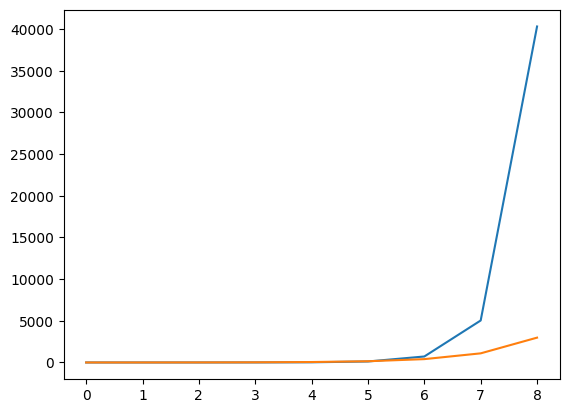

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

x = list(range(0, 9))
y = [factorial(i) for i in x]
z = list(map(math.exp, x))

x = np.array(x)
y = np.array(y)
z = np.array(z)

plt.plot(x, y) # fact(n)
plt.plot(x, z) # e^n

Asymptotical behaviour of n! (Stirling's approximation):

$$n! \approx \sqrt{2 \pi n} \left(\frac{n}{e}\right)^n$$

When $n \rightarrow \infty$

You will see this again in some future courses (algorithms, probability ...)

### Combination

In mathematics, combinations refer to the combination of n things taken k at a time without
repetition. There is a recursive formula related to combinations:

$$ {n \choose k} = {n-1 \choose k-1} + {n-1 \choose k}$$

$$C(n, k) = C(n-1, k-1) + C(n-1, k)$$

And ${n \choose 0} = {n \choose n} = 1$, ${n \choose k} = 0$ if $k > n$.




In [ ]:
def C(n, k):
    """Return the number of combinations of n items taken k at a time."""
    if k > n:
        return 0
    elif k == 0 or k == n:
        return 1
    else:
        return C(n-1, k-1)+C(n-1,k)
    
if __name__ == "__main__":
    print(C(5, 2))  # Output: 10
    print(C(2, 5))  # Output: 0

A little bit more about combinations.

$${n \choose k} = \frac{n!}{k!(n-k)!}$$

An combinatorial interpretation of $ {n \choose k} = {n-1 \choose k-1} + {n-1 \choose k} $

Choose a specific item A from the n items. 
- If A is included in the selection, we need to choose k-1 items from the remaining n-1 items. There are ${n-1 \choose k-1}$ ways to do this.
- If A is not included in the selection, we need to choose k items from the remaining n-1 items. There are ${n-1 \choose k}$ ways to do this.

You will learn more about combinatorics in future courses (COMP2121, STAT2601 ...).

### Ackermann function

Implement Ackermann function by recursive function calls. Ackermann function is defined as follows:

$$ A(m,n) = \begin{cases} n + 1 &\text{if}& m = 0 \\
A(m - 1, 1) &\text{if}& m > 0 \text{ and } n = 0 \\
A(m - 1, A(m, n - 1)) &\text{if}& m > 0 \text{ and } n > 0
\end{cases}

In [ ]:
def Ackermann(m, n):
    """Return the Ackermann function A(m, n)."""
    if m == 0:
        return n+1
    elif m > 0 and n == 0:
        return Ackermann(m-1,1)
    else:
        return Ackermann(m-1, Ackermann(m,n-1))
    
if __name__ == "__main__":
    print(Ackermann(1, 2))  
    print(Ackermann(4, 0))  

4
13


Does this function terminate for all non-negative integers m and n? 

\[Demo\]

You may wonder why we care about such a weird function.
The Ackermann function is a classic example in computer science and mathematics that illustrates the concept of computability. It can also be used to test the optimization and efficiency of compilers and interpreters, as it grows very quickly even for small inputs.

### Base conversion

Complete the code below by defining a recursive function `convert_base(n, b)` which converts a
decimal integer n to a string in base b. You may assume the input n is an integer in decimal and
the input b is in the range 2 to 16, inclusively.

35 = 2 * 17 + 1
17 = 2 * 8 + 1 
8 = 2 * 4 + 0
4 = 2 * 2 + 0
2 = 2 * 1 + 0
1 = 2 * 0 + 1

convert_base(35, 2) = "100011"
convert_base(17, 2) = "10001"


In [10]:
digits = "0123456789ABCDEF"

def convert_base(n, b) -> str: # convert_base(17, 2)
    # n = 35, b = 2
    """Convert non-negative integer n to its representation in base b."""
    if n == 0:
        return ""
    else:
        return convert_base(n // b, b) + digits[n % b] # convert(17, 2) + "1"


if __name__ == "__main__":
    print(convert_base(10, 2))  # Output: '1010'
    print(convert_base(255, 16))  # Output: 'FF'

1010
FF


In [ ]:
a = 0xFF
b = 0b110
c = 1_000_000
d = 1e6

## 3. Recursion Examples

### Sierpinski Triangle

<img src="./assets/sier.jpg" alt="Sierpinski Triangle" width="400"/>

### An example of mutual recursion

Summing up the digits of an integer n in decimal representation.

1234 -> $4 + 3 + 2 + 1 = 10$ `sum_digit(123) + 4`

Summing up the digits of an integer n with twice the odd digits (counting from right to left).

E.g., 1234 -> $4\times2 + 3 + 2\times2 + 1 = 16$

In [2]:
def sum_digit(n):
    if n < 10:
        return n
    else:
        return sum_digit(n//10) + n % 10    

sum_digit(1234)

10

In [ ]:
def sum_odd(n):
    if n < 10:
        return n*2
    else:
        return sum_even(n//10) + (n % 10) * 2
    
def sum_even(n):
    if n < 10:
        return n
    else:
        return sum_odd(n//10) + n % 10

# 1234
# sum_odd(1234) = sum_even(123) + 4 * 2
# sum_even(123) = sum_odd(12) + 3
# sum_odd(12) = sum_even(1) + 2 * 2
# sum_even(1) = 1

The notes will be uploaded as PDF later!

In [7]:
s = "5190990281925290"

check = s[-1]
payload = s[:-1]

luhn_sum = 0

for idx, i in enumerate(payload[::-1]):
    if idx % 2 == 1:
        luhn_sum += int(i)
    else:
        num = 2*int(i)
        luhn_sum += sum_digit(num)

print(luhn_sum)
print(f"checker digit: {10 - luhn_sum%10}")


62
checker digit: 8
